## Website Performance Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# read dataset
df = pd.read_csv("website_dataset.csv")
df.head(5)

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [18]:
# creat first row as header

df.columns = df.iloc[0]   # create first row as column name
df = df[1:]               # remove first row
df.reset_index(drop=True, inplace=True)

df.head(5)

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [24]:
# Change column names
df.columns = ["channel_group", "date_hour", "users", "sessions", "engaged_sessions", "average_engagement_time_per_session", "engaged_sessions_per_user", "events_per_session", "engagement_rate", "event_count"]

In [26]:
df.head(4)

,channel_group,date_hour,users,sessions,engaged_sessions,average_engagement_time_per_session,engaged_sessions_per_user,events_per_session,engagement_rate,event_count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel_group                        3182 non-null   object
 1   date_hour                            3182 non-null   object
 2   users                                3182 non-null   object
 3   sessions                             3182 non-null   object
 4   engaged_sessions                     3182 non-null   object
 5   average_engagement_time_per_session  3182 non-null   object
 6   engaged_sessions_per_user            3182 non-null   object
 7   events_per_session                   3182 non-null   object
 8   engagement_rate                      3182 non-null   object
 9   event_count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [48]:
# change datatypes of the columns
exclude_columns = ["channel_group", "date_hour"]
cols_to_convert = df.columns.drop(exclude_columns)
df.loc[:, cols_to_convert] = df.loc[:, cols_to_convert].apply(
    pd.to_numeric, errors='coerce'
)

In [50]:
# creat hour column and change date_hour datatype
df["date_hour"] = pd.to_datetime(df["date_hour"], format="%Y%m%d%H", errors="coerce")
df["hour"] = df["date_hour"].dt.hour

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel_group                        3182 non-null   object        
 1   date_hour                            3182 non-null   datetime64[ns]
 2   users                                3182 non-null   int64         
 3   sessions                             3182 non-null   int64         
 4   engaged_sessions                     3182 non-null   int64         
 5   average_engagement_time_per_session  3182 non-null   float64       
 6   engaged_sessions_per_user            3182 non-null   float64       
 7   events_per_session                   3182 non-null   float64       
 8   engagement_rate                      3182 non-null   float64       
 9   event_count                          3182 non-null   int64         
 10  hour        

In [54]:
df.isnull().sum()

channel_group                          0
date_hour                              0
users                                  0
sessions                               0
engaged_sessions                       0
average_engagement_time_per_session    0
engaged_sessions_per_user              0
events_per_session                     0
engagement_rate                        0
event_count                            0
hour                                   0
dtype: int64

In [58]:
df.describe()

,date_hour,users,sessions,engaged_sessions,average_engagement_time_per_session,engaged_sessions_per_user,events_per_session,engagement_rate,event_count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


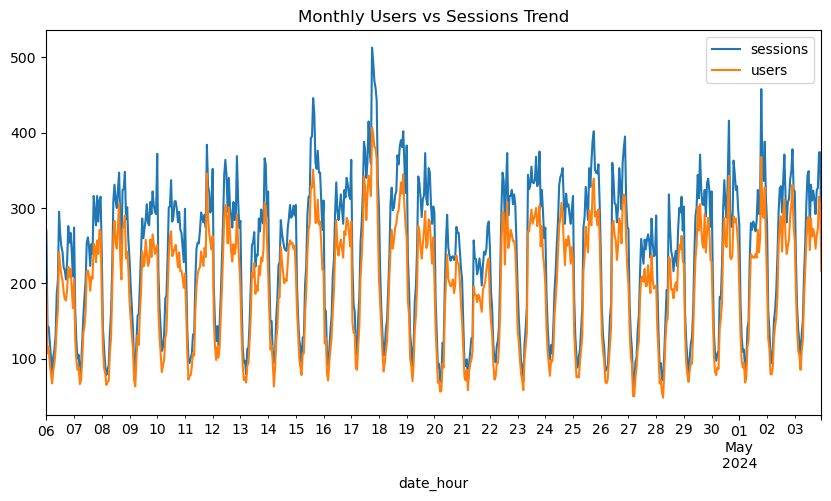

In [68]:
# sort by date 
df = df.sort_values('date_hour')

plt.figure(figsize=(10,5))

df.groupby("date_hour")[["sessions", "users"]].sum().plot(ax=plt.gca())
plt.title("Monthly Users vs Sessions Trend")

plt.show()